In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('E:/Portfolio Project/Manufacturing Plant Operational Performance & Root Cause Analysis/data/raw_file/Manufacturing Dataset.csv')

In [19]:
df.head()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,01-01-2018,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,01-01-1900,02-01-2018,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,02-01-1900,03-01-2018,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,03-01-1900,04-01-2018,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,04-01-1900,05-01-2018,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [20]:
df.tail()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
2995,2999,17-03-2026,Furniture,20,Swing,199,3.0,1.01,24.35,29.73,245.47,3,2.73,0.26,0.93,0.029,1.26,1,24.9,56.3
2996,3000,18-03-2026,Appliances,12,Night,121,2.0,5.36,12.41,22.96,221.97,3,0.07,NaN,2.18,0.018,1.07,2,19.9,37.8
2997,3001,19-03-2026,Automotive,4,Night,106,4.0,23.51,36.33,16.45,231.71,2,0.22,2.13,2.19,0.045,0.65,0,18.8,54.7
2998,3002,20-03-2026,Electronics,15,Swing,196,6.0,9.23,10.78,27.69,300.27,1,2.00,0.95,0.96,0.033,1.06,0,24.0,46.9
2999,3003,21-03-2026,Electronics,15,Night,93,2.0,21.44,23.77,24.58,296.92,2,2.40,1.25,1.37,0.016,1.99,2,24.8,39.1


In [21]:
df.describe()

,Machine ID,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
count,3000.000000,3000.000000,2701.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2700.000000,2700.000000,3000.000000,3000.000000,2700.000000,3000.000000,3000.000000,3000.000000
mean,10.259000,125.037667,4.612736,12.577697,30.206220,22.642937,299.895430,2.495000,2.507167,1.533941,1.512730,0.030255,1.002885,1.002667,21.601833,45.008333
std,5.752821,43.566718,3.201673,6.910378,11.726906,4.396858,114.987552,1.117911,1.444322,0.878036,0.576816,0.011467,0.578608,0.802625,2.045904,8.586297
min,1.000000,50.000000,0.000000,1.000000,3.000000,15.000000,100.040000,1.000000,0.000000,0.000000,0.500000,0.010000,0.000000,0.000000,18.000000,30.000000
25%,5.000000,86.000000,2.000000,6.797500,20.320000,18.810000,199.050000,2.000000,1.240000,0.780000,1.017500,0.020000,0.500000,0.000000,19.800000,37.500000
50%,10.000000,126.000000,4.000000,12.400000,30.045000,22.770000,300.160000,2.000000,2.490000,1.570000,1.510000,0.030000,1.010000,1.000000,21.700000,45.000000
75%,15.000000,163.000000,7.000000,18.332500,40.122500,26.492500,401.145000,4.000000,3.760000,2.300000,2.010000,0.040000,1.490000,2.000000,23.400000,52.200000
max,20.000000,199.000000,34.000000,50.000000,65.000000,30.000000,499.960000,4.000000,5.000000,3.000000,2.500000,0.050000,2.000000,2.000000,25.000000,60.000000


In [16]:
## check the data types of every columns.
df.dtypes

Production ID                         str
Date                                  str
Product Type                          str
Machine ID                          int64
Shift                                 str
Units Produced                      int64
Defects                           float64
Production Time Hours             float64
Material Cost Per Unit            float64
Labour Cost Per Hour              float64
Energy Consumption kWh            float64
Operator Count                      int64
Maintenance Hours                 float64
Down time Hours                   float64
Production Volume Cubic Meters    float64
Scrap Rate                        float64
Rework Hours                      float64
Quality Checks Failed               int64
Average Temperature C             float64
Average Humidity Percent          float64
dtype: object

# Changing Data Types

## Objects to Category

In [22]:
df.select_dtypes(include='object').columns

Index(['Production ID', 'Date', 'Product Type', 'Shift'], dtype='str')

the date column is strung data type so.
chage it into date datatype.

In [23]:
df['Production ID']=df['Production ID'].astype('category')

In [24]:
df['Product Type']=df['Product Type'].astype('category')

In [25]:
df['Shift']=df['Shift'].astype('category')

## Numeric to Objects

In [26]:
df['Machine ID']=df['Machine ID'].astype('category')

In [27]:
df.select_dtypes(include='category').columns

Index(['Production ID', 'Product Type', 'Machine ID', 'Shift'], dtype='str')

## Objects to Numeric

In [28]:
df.select_dtypes(include='object').columns

Index(['Date'], dtype='str')

In [30]:
df.Date=pd.to_datetime(df.Date, format='%d-%m-%Y')

Adding a month column as we have to find month on month trend

In [31]:
import datetime

In [32]:
df['month']=df.Date.apply(lambda x:x.month_name())
df['month']=df['month'].astype('category')

In [33]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent', 'month'],
      dtype='str')

In [34]:
df.dtypes

Production ID                           category
Date                              datetime64[us]
Product Type                            category
Machine ID                              category
Shift                                   category
Units Produced                             int64
Defects                                  float64
Production Time Hours                    float64
Material Cost Per Unit                   float64
Labour Cost Per Hour                     float64
Energy Consumption kWh                   float64
Operator Count                             int64
Maintenance Hours                        float64
Down time Hours                          float64
Production Volume Cubic Meters           float64
Scrap Rate                               float64
Rework Hours                             float64
Quality Checks Failed                      int64
Average Temperature C                    float64
Average Humidity Percent                 float64
month               

# EDA

In [35]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Production ID                       0
Date                                0
Product Type                        0
Machine ID                          0
Shift                               0
Units Produced                      0
Defects                           299
Production Time Hours               0
Material Cost Per Unit              0
Labour Cost Per Hour                0
Energy Consumption kWh              0
Operator Count                      0
Maintenance Hours                 300
Down time Hours                   300
Production Volume Cubic Meters      0
Scrap Rate                          0
Rework Hours                      300
Quality Checks Failed               0
Average Temperature C               0
Average Humidity Percent            0
month                               0
dtype: int64


## 1. Dealing with IQR using outlier

- Calculate the Interquartile Range (IQR) for all the numerical columns and use the IQR to identify any potential outliers in these data points.

In [36]:
col=df.select_dtypes(exclude=['category','datetime64[ns]'])
col.columns

Index(['Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent'],
      dtype='str')

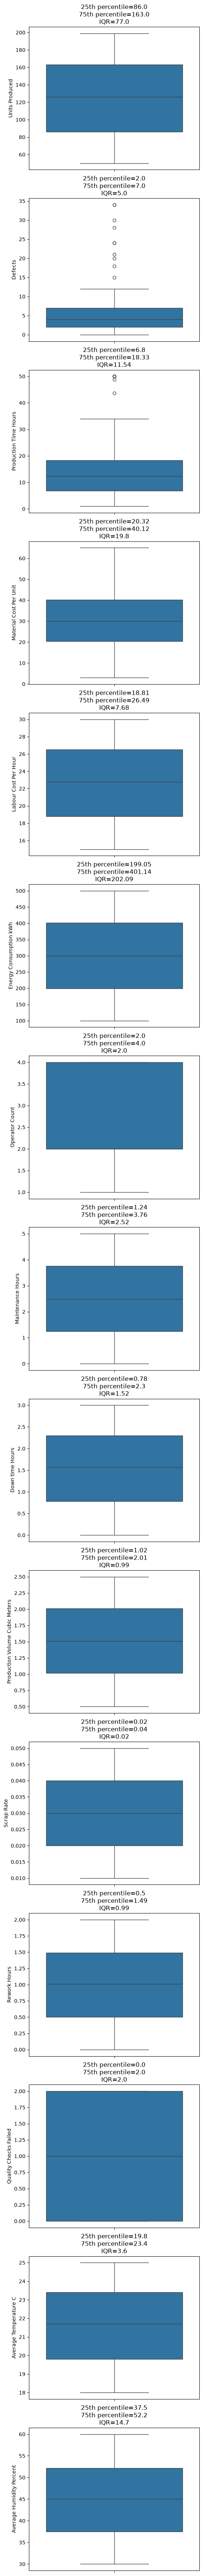

In [44]:
plt.figure(figsize=(6,6*len(col.columns)))
for i,j in enumerate(col.columns):
    plt.subplot(len(col.columns),1,i+1)
    sns.boxplot(df[j])
    p25,p75=np.percentile(df[j].dropna(),25),np.percentile(df[j].dropna(),75)
    IQR=p75-p25
    plt.title(f'25th percentile={round(p25,2)}\n75th percentile={round(p75,2)}\nIQR={round(IQR,2)}')
    
    

From the box plot we can say that only defects and production time hours have outliers.

## 2. Identify Missing Values Across Key Production Metrics:

Analyse the dataset to identify missing values across all the columns and calculate the total number of missing values for each of these columns. 

In [46]:
df.isna().sum()

Production ID                       0
Date                                0
Product Type                        0
Machine ID                          0
Shift                               0
Units Produced                      0
Defects                           299
Production Time Hours               0
Material Cost Per Unit              0
Labour Cost Per Hour                0
Energy Consumption kWh              0
Operator Count                      0
Maintenance Hours                 300
Down time Hours                   300
Production Volume Cubic Meters      0
Scrap Rate                          0
Rework Hours                      300
Quality Checks Failed               0
Average Temperature C               0
Average Humidity Percent            0
month                               0
dtype: int64

Defects, Maintenece Hours, Down time Hours and Rework Hours have missing values.

We will check if there is some pattern in the data and if the missing values can be imputed, else we will delete the missing values

Imputing for defects

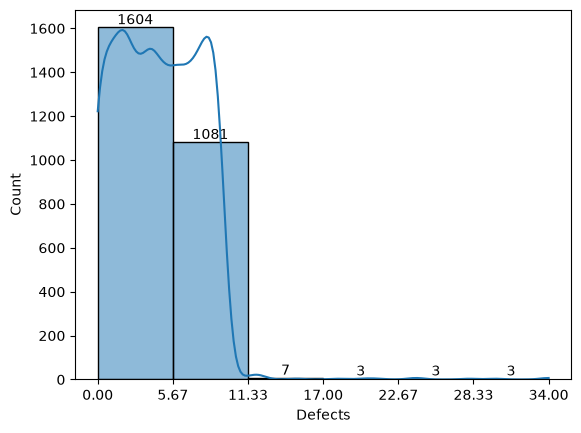

In [47]:
ax=sns.histplot(df.Defects,bins=6,kde=True)
ax.bar_label(ax.containers[0])
plt.xticks(np.arange(df.Defects.min(),df.Defects.max()+1,(df.Defects.max()-df.Defects.min())/6))
plt.show()

In [53]:
print("mean: ",df.Defects.mean())
print("median: ",df.Defects.median()) 
print("mode: ",df.Defects.mode())

mean:  4.612736023694928
median:  4.0
mode:  0    9.0
Name: Defects, dtype: float64


As Defects has outlies and the data of defects is right skewed. So median is better option for imputing.

In [64]:
# Fill missing values in Defects column

df['Defects'] = df['Defects'].fillna(df['Defects'].median(), inplace = True)


In [65]:
df.isna().sum()

Production ID                       0
Date                                0
Product Type                        0
Machine ID                          0
Shift                               0
Units Produced                      0
Defects                             0
Production Time Hours               0
Material Cost Per Unit              0
Labour Cost Per Hour                0
Energy Consumption kWh              0
Operator Count                      0
Maintenance Hours                 300
Down time Hours                   300
Production Volume Cubic Meters      0
Scrap Rate                          0
Rework Hours                      300
Quality Checks Failed               0
Average Temperature C               0
Average Humidity Percent            0
month                               0
dtype: int64

***Imputing for Maintenance Hours***

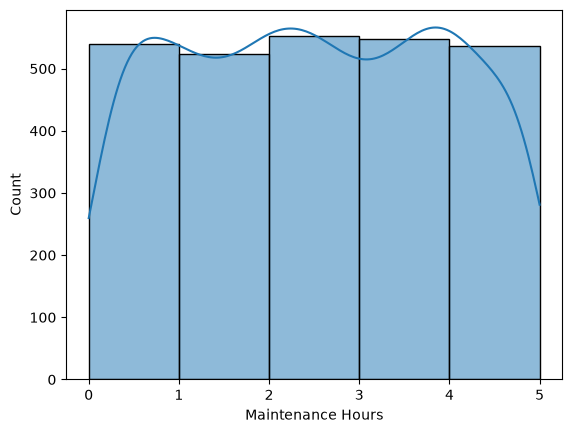

In [67]:
x=sns.histplot(df['Maintenance Hours'],bins=5,kde=True)
ax.bar_label(ax.containers[0])
plt.xticks(np.arange(df['Maintenance Hours'].min(),df['Maintenance Hours'].max()+1,(df['Maintenance Hours'].max()-df['Maintenance Hours'].min())/5))
plt.show()

In [75]:
print("mean: ", df['Maintenance Hours'].mean())
print("median: ", df['Maintenance Hours'].median())
print("mode: ", df['Maintenance Hours'].mode())

mean:  2.5071666666666665
median:  2.49
mode:  0    4.10
1    4.62
Name: Maintenance Hours, dtype: float64


The data has no outliers and It is symentrically distributed. Can use mean for imputation

In [76]:
df['Maintenance Hours'] = df['Maintenance Hours'].fillna(df['Maintenance Hours'].mean(), inplace = True)

In [77]:
df['Maintenance Hours'].isna().sum()

np.int64(0)

Imputing for Down time hours

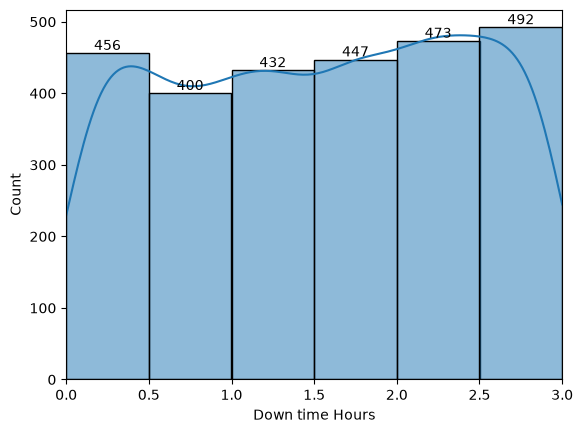

In [87]:
ax=sns.histplot(df['Down time Hours'],bins=6, kde=True)
ax.bar_label(ax.containers[0])
plt.xticks(np.arange(df['Down time Hours'].min(),df['Down time Hours'].max()+1,(df['Down time Hours'].max()-df['Down time Hours'].min())/6))
plt.xlim(df['Down time Hours'].min(),df['Down time Hours'].max())
plt.show()

In [ ]:
print('Mean: ', df['Down time Hours'].mean())
print('Median: ', df['Down time Hours'].median())
print('Mode: ', df['Down time Hours'].mode())

Mean:  1.5339407407407408
Median:  1.57
Mode:  0    1.88
1    2.48
2    2.60
3    2.64
Name: Down time Hours, dtype: float64


Almost symetric distribution with no outliers . will use median value for imputation.

In [88]:
df['Down time Hours'] = df['Down time Hours'].fillna(df['Down time Hours'].median(), inplace = True)

In [89]:
df['Down time Hours'].isna().sum()

np.int64(0)

Imputing for Rework Hours

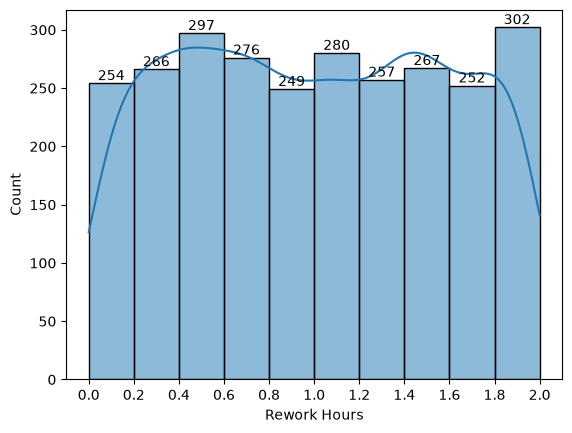

In [ ]:
ax=sns.histplot(df['Rework Hours'],bins=10,kde=True)

ax.bar_label(ax.containers[0])
plt.xticks(np.arange(df['Rework Hours'].min(),df['Rework Hours'].max()+0.1,(df['Rework Hours'].max()-df['Rework Hours'].min())/10))
plt.show()


In [92]:
print('Mean: ', df['Rework Hours'].mean())
print ('Median: ', df['Rework Hours'].median())
print( 'Mode: ', df['Rework Hours'].mode())

Mean:  1.0028851851851852
Median:  1.01
Mode:  0    1.83
Name: Rework Hours, dtype: float64


Symetric ditribution with no outliers. use mean for imputation

In [93]:
df['Rework Hours'] = df['Rework Hours'].fillna(df['Rework Hours'].mean(), inplace = True)

In [94]:
df.isna().sum()

Production ID                     0
Date                              0
Product Type                      0
Machine ID                        0
Shift                             0
Units Produced                    0
Defects                           0
Production Time Hours             0
Material Cost Per Unit            0
Labour Cost Per Hour              0
Energy Consumption kWh            0
Operator Count                    0
Maintenance Hours                 0
Down time Hours                   0
Production Volume Cubic Meters    0
Scrap Rate                        0
Rework Hours                      0
Quality Checks Failed             0
Average Temperature C             0
Average Humidity Percent          0
month                             0
dtype: int64

Now the data has no missing value

##  Relationship Between Costs:

- Is there a pattern between the cost of materials per unit and the hourly labor cost? Determine if higher costs in materials tend to coincide with higher labor costs.

In [95]:
target=df[['Material Cost Per Unit','Labour Cost Per Hour']]
for i in ['spearman','pearson','kendall']:
    print(f"{i} correlation coefficient:\n {target.corr(i)} \n")


spearman correlation coefficient:
                         Material Cost Per Unit  Labour Cost Per Hour
Material Cost Per Unit                1.000000              0.000667
Labour Cost Per Hour                  0.000667              1.000000 

pearson correlation coefficient:
                         Material Cost Per Unit  Labour Cost Per Hour
Material Cost Per Unit                1.000000             -0.000004
Labour Cost Per Hour                 -0.000004              1.000000 

kendall correlation coefficient:
                         Material Cost Per Unit  Labour Cost Per Hour
Material Cost Per Unit                1.000000              0.000346
Labour Cost Per Hour                  0.000346              1.000000 



<Axes: xlabel='Material Cost Per Unit', ylabel='Labour Cost Per Hour'>

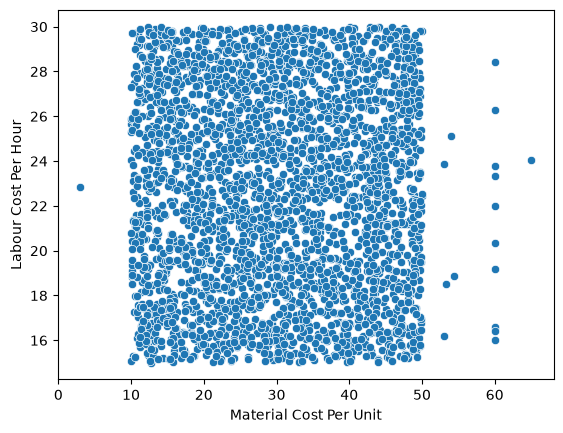

In [97]:
sns.scatterplot(x=df['Material Cost Per Unit'],y=df['Labour Cost Per Hour'])

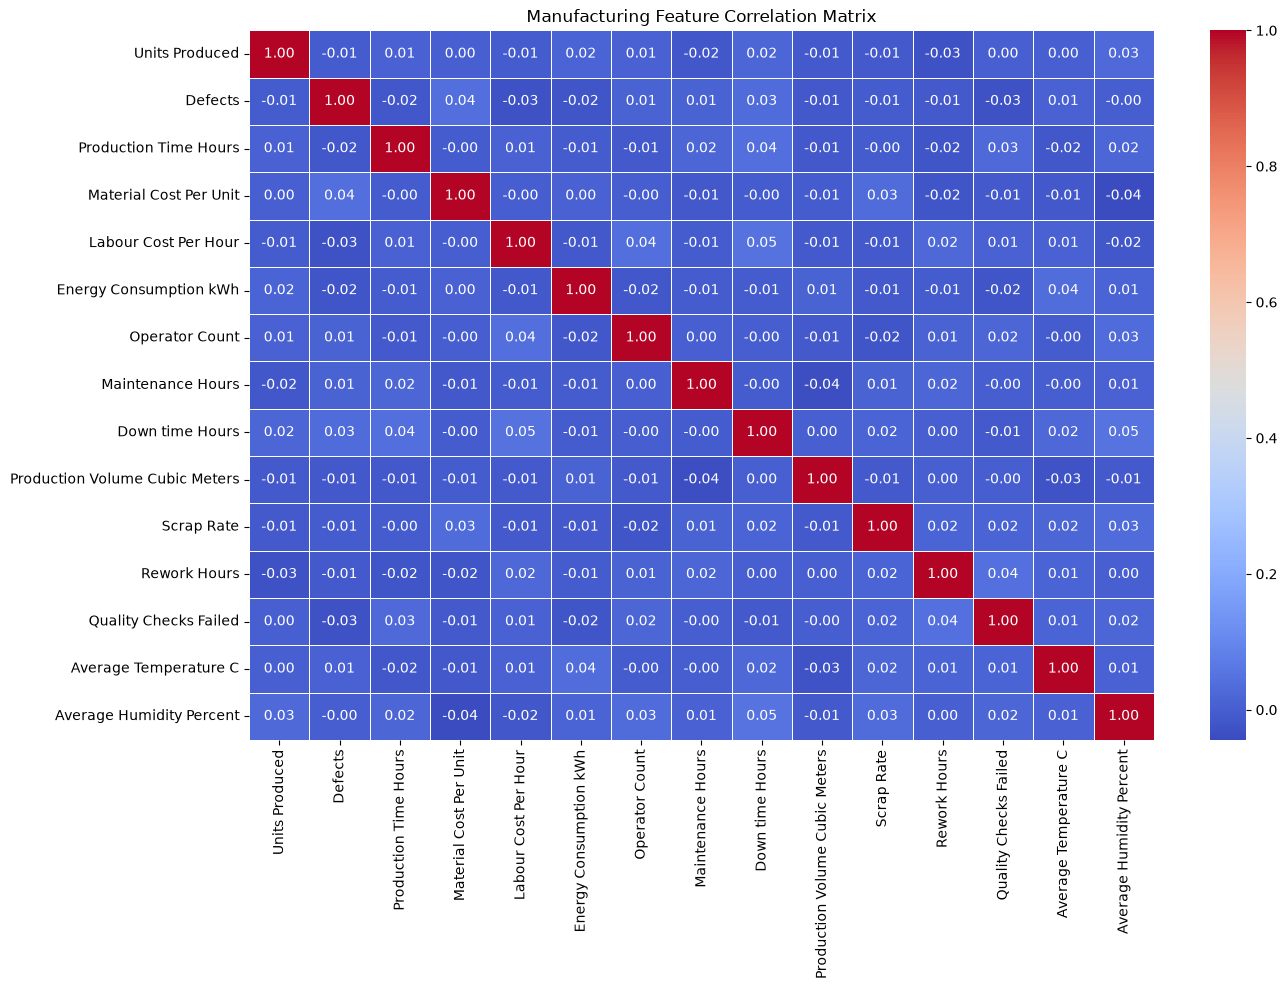

In [96]:
plt.figure(figsize=(14, 10))
# Selecting numerical columns for matrix correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Manufacturing Feature Correlation Matrix')
plt.tight_layout()
plt.show()

No significant correlation is found among the features

## Efficiency Across Shifts:

- Do different work shifts (Day, Swing, Night) show differences in how long products take to make or how much energy they use? Compare these shifts to see if one is more efficient or uses less energy.

[Text(0, 0, '982'), Text(0, 0, '1009'), Text(0, 0, '1009')]

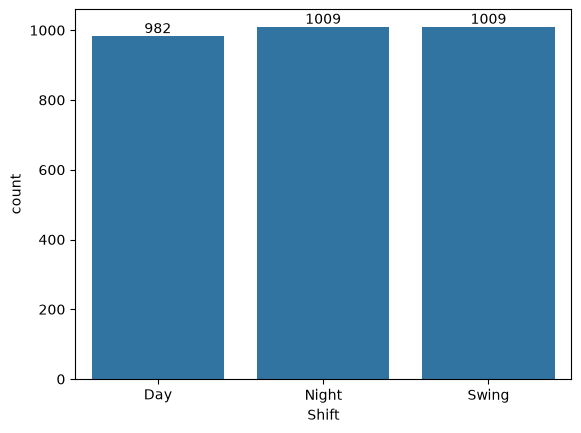

In [98]:
ax1=sns.countplot(x=df.Shift,order=df.Shift.value_counts(ascending=True).index)
ax1.bar_label(ax1.containers[0])

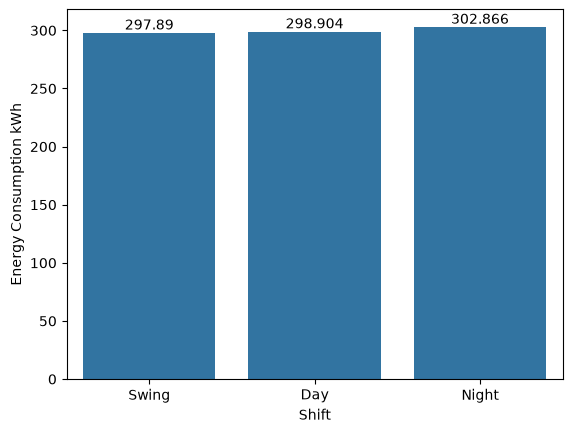

In [100]:
a=df.groupby('Shift')['Energy Consumption kWh'].mean()
aa=pd.DataFrame(a)
aa.sort_values('Energy Consumption kWh')

ax2=sns.barplot(width=0.8,y=df['Energy Consumption kWh'],x=df.Shift,errorbar=None,order=aa.sort_values('Energy Consumption kWh').index)
ax2.bar_label(ax2.containers[0])
plt.show()

In [102]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Swing'),'Energy Consumption kWh'],
    b=df.loc[df.Shift=='Day','Energy Consumption kWh'],
    alternative='two-sided')

TtestResult(statistic=np.float64(-0.19738519095298937), pvalue=np.float64(0.8435462859275904), df=np.float64(1989.0))

Energy consumption is essentially the SAME for both shifts

- Swing shift: ~[mean_value] kWh
- Day shift:  ~[mean_value] kWh
- Difference: ~[very small] kWh (not meaningful)

In [103]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Night'),'Energy Consumption kWh'],
    b=df.loc[df.Shift=='Day','Energy Consumption kWh'],
    alternative='two-sided')

TtestResult(statistic=np.float64(0.7663438998366511), pvalue=np.float64(0.4435626431172725), df=np.float64(1989.0))

In [104]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Swing'),'Energy Consumption kWh'],
    b=df.loc[df.Shift=='Night','Energy Consumption kWh'],
    alternative='two-sided')

TtestResult(statistic=np.float64(-0.9707522916725697), pvalue=np.float64(0.3317880963926267), df=np.float64(2016.0))

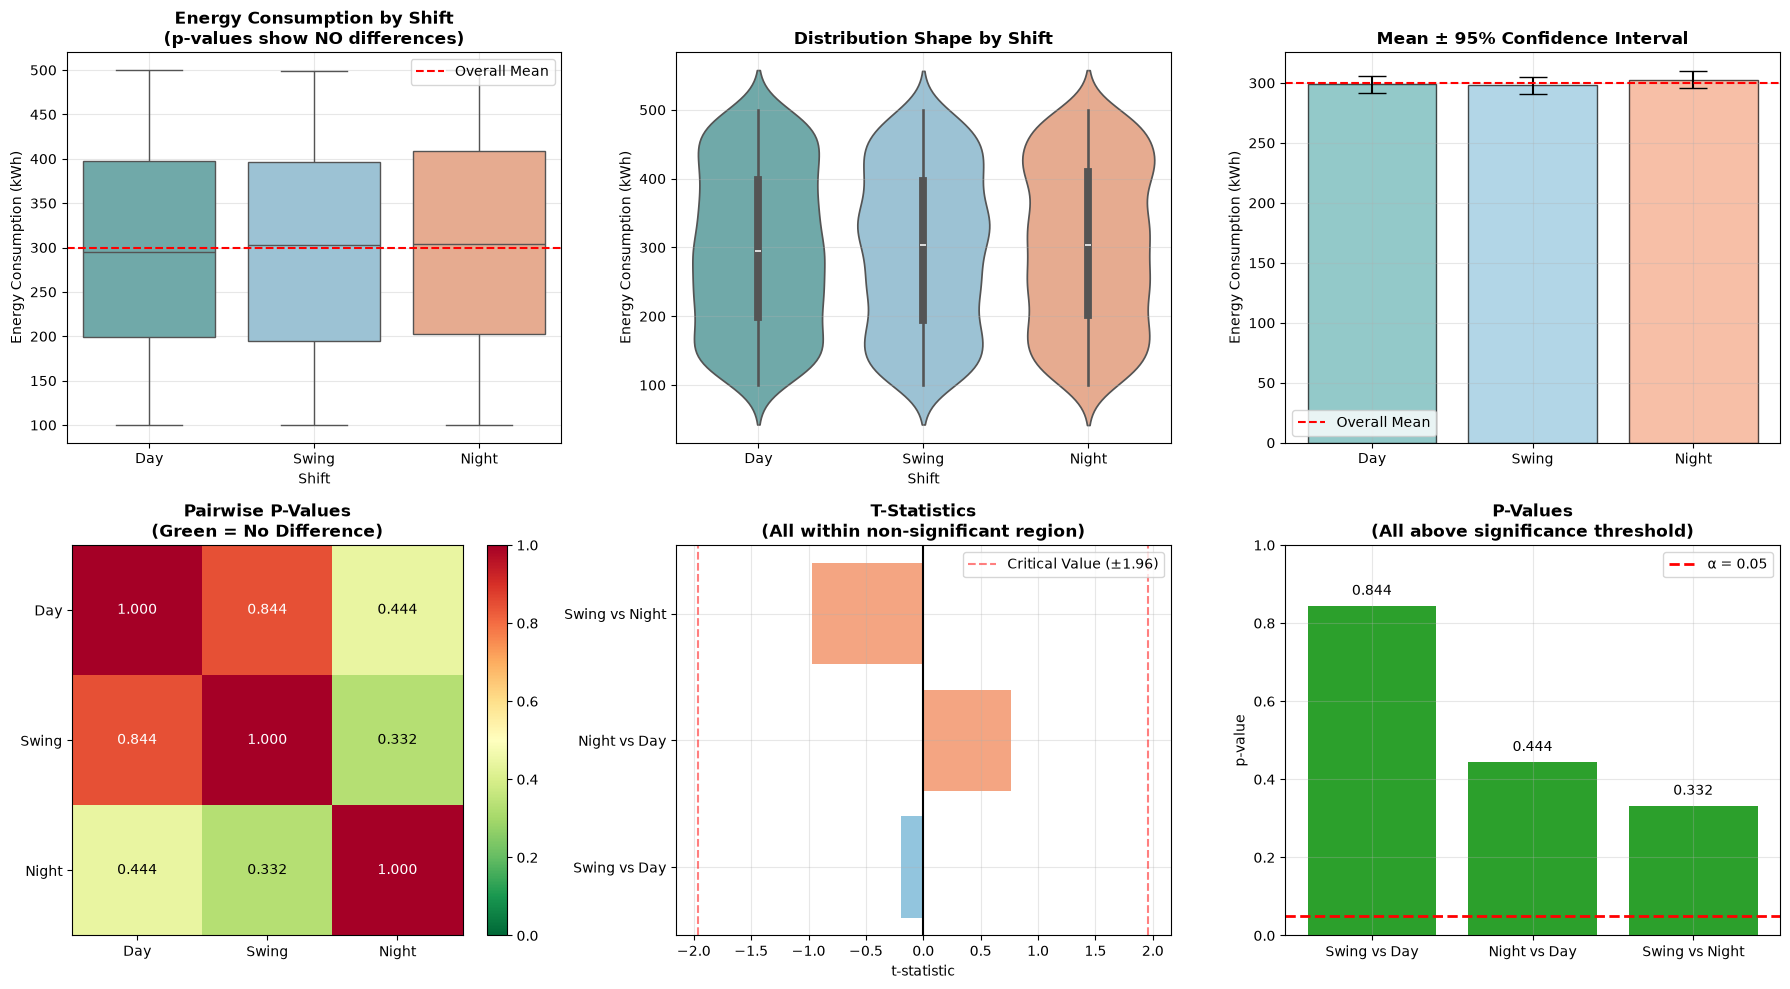

In [106]:


# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Box Plot Comparison
ax1 = axes[0, 0]
# Assuming you have your DataFrame 'df'
sns.boxplot(df, x='Shift', y='Energy Consumption kWh', 
            order=['Day', 'Swing', 'Night'], 
            palette=['#66b3b2', '#92c5de', '#f4a582'], ax=ax1)
ax1.set_title('Energy Consumption by Shift\n(p-values show NO differences)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.axhline(y=df['Energy Consumption kWh'].mean(), color='red', 
            linestyle='--', label='Overall Mean')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Violin Plot (shows distribution shape)
ax2 = axes[0, 1]
sns.violinplot(df, x='Shift', y='Energy Consumption kWh',
               order=['Day', 'Swing', 'Night'],
               palette=['#66b3b2', '#92c5de', '#f4a582'], ax=ax2)
ax2.set_title('Distribution Shape by Shift', fontsize=12, fontweight='bold')
ax2.set_ylabel('Energy Consumption (kWh)')
ax2.grid(True, alpha=0.3)

# 3. Mean Comparison with Confidence Intervals
ax3 = axes[0, 2]
means = df.groupby('Shift')['Energy Consumption kWh'].mean().reindex(['Day', 'Swing', 'Night'])
stds = df.groupby('Shift')['Energy Consumption kWh'].std().reindex(['Day', 'Swing', 'Night'])
n = df.groupby('Shift')['Energy Consumption kWh'].count().reindex(['Day', 'Swing', 'Night'])

# Calculate standard errors
se = stds / np.sqrt(n)
ci_lower = means - 1.96 * se
ci_upper = means + 1.96 * se

x_pos = np.arange(len(means))
ax3.bar(x_pos, means, yerr=1.96*se, capsize=10, 
        color=['#66b3b2', '#92c5de', '#f4a582'],
        alpha=0.7, edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(means.index)
ax3.set_title('Mean ± 95% Confidence Interval', fontsize=12, fontweight='bold')
ax3.set_ylabel('Energy Consumption (kWh)')
ax3.axhline(y=df['Energy Consumption kWh'].mean(), color='red', 
            linestyle='--', label='Overall Mean')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. P-value Heatmap
ax4 = axes[1, 0]
p_values = np.array([
    [1, 0.844, 0.444],
    [0.844, 1, 0.332],
    [0.444, 0.332, 1]
])
im = ax4.imshow(p_values, cmap='RdYlGn_r', vmin=0, vmax=1)
ax4.set_xticks(range(3))
ax4.set_yticks(range(3))
ax4.set_xticklabels(['Day', 'Swing', 'Night'])
ax4.set_yticklabels(['Day', 'Swing', 'Night'])
ax4.set_title('Pairwise P-Values\n(Green = No Difference)', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax4.text(j, i, f'{p_values[i, j]:.3f}',
                       ha="center", va="center", color="black" if p_values[i, j] < 0.7 else "white")
plt.colorbar(im, ax=ax4)

# 5. T-statistics Visualization
ax5 = axes[1, 1]
comparisons = ['Swing vs Day', 'Night vs Day', 'Swing vs Night']
t_stats = [-0.197, 0.766, -0.971]
colors_bar = ['#92c5de' if abs(x) < 0.5 else '#f4a582' if abs(x) < 1 else '#d73027' for x in t_stats]

bars = ax5.barh(comparisons, t_stats, color=colors_bar)
ax5.axvline(0, color='black', linewidth=1.5)
ax5.axvline(-1.96, color='red', linestyle='--', alpha=0.5, label='Critical Value (±1.96)')
ax5.axvline(1.96, color='red', linestyle='--', alpha=0.5)
ax5.set_title('T-Statistics\n(All within non-significant region)', fontsize=12, fontweight='bold')
ax5.set_xlabel('t-statistic')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. p-value Bar Chart
ax6 = axes[1, 2]
p_vals = [0.844, 0.444, 0.332]
colors_p = ['#2ca02c' if x > 0.05 else '#d62728' for x in p_vals]

bars = ax6.bar(comparisons, p_vals, color=colors_p)
ax6.axhline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax6.set_title('P-Values\n(All above significance threshold)', fontsize=12, fontweight='bold')
ax6.set_ylabel('p-value')
ax6.set_ylim(0, 1)
ax6.legend()
ax6.grid(True, alpha=0.3)

# Add p-value labels on bars
for bar, p_val in zip(bars, p_vals):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{p_val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

KEY FINDINGS:
1. ALL three shifts show statistically similar energy consumption
2. The small differences observed are due to random variation
3. No shift is significantly more energy-efficient than others

 IMPLICATIONS:
1. Shift scheduling does NOT impact energy consumption
2. Energy efficiency is consistent across all operating hours
3. No need for shift-specific energy policies or incentives

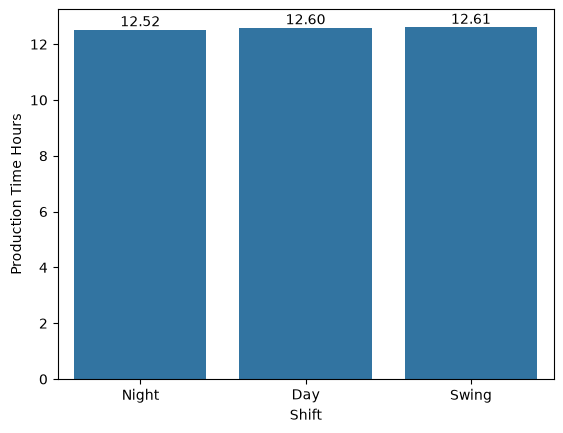

In [107]:
a=df.groupby('Shift')['Production Time Hours'].mean()
aa=pd.DataFrame(a)
aa.sort_values('Production Time Hours')
ax=sns.barplot(y=df['Production Time Hours'],x=df.Shift,errorbar=None,
               order=aa.sort_values('Production Time Hours').index)
ax.bar_label(ax.containers[0],fmt="%0.2f")
plt.show()

In [109]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Swing'),'Production Time Hours'],
    b=df.loc[df.Shift=='Day','Production Time Hours'],
    alternative='two-sided')

TtestResult(statistic=np.float64(0.05766697444453557), pvalue=np.float64(0.954019692959308), df=np.float64(1989.0))

In [110]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Swing'),'Production Time Hours'],
    b=df.loc[df.Shift=='Night','Production Time Hours'],
    alternative='two-sided')

TtestResult(statistic=np.float64(0.2945847104443192), pvalue=np.float64(0.7683414731667173), df=np.float64(2016.0))

In [111]:
sci.ttest_ind(
    a=df.loc[(df.Shift=='Day'),'Production Time Hours'],
    b=df.loc[df.Shift=='Night','Production Time Hours'],
    alternative='two-sided')

TtestResult(statistic=np.float64(0.22934786903064977), pvalue=np.float64(0.8186221312371268), df=np.float64(1989.0))

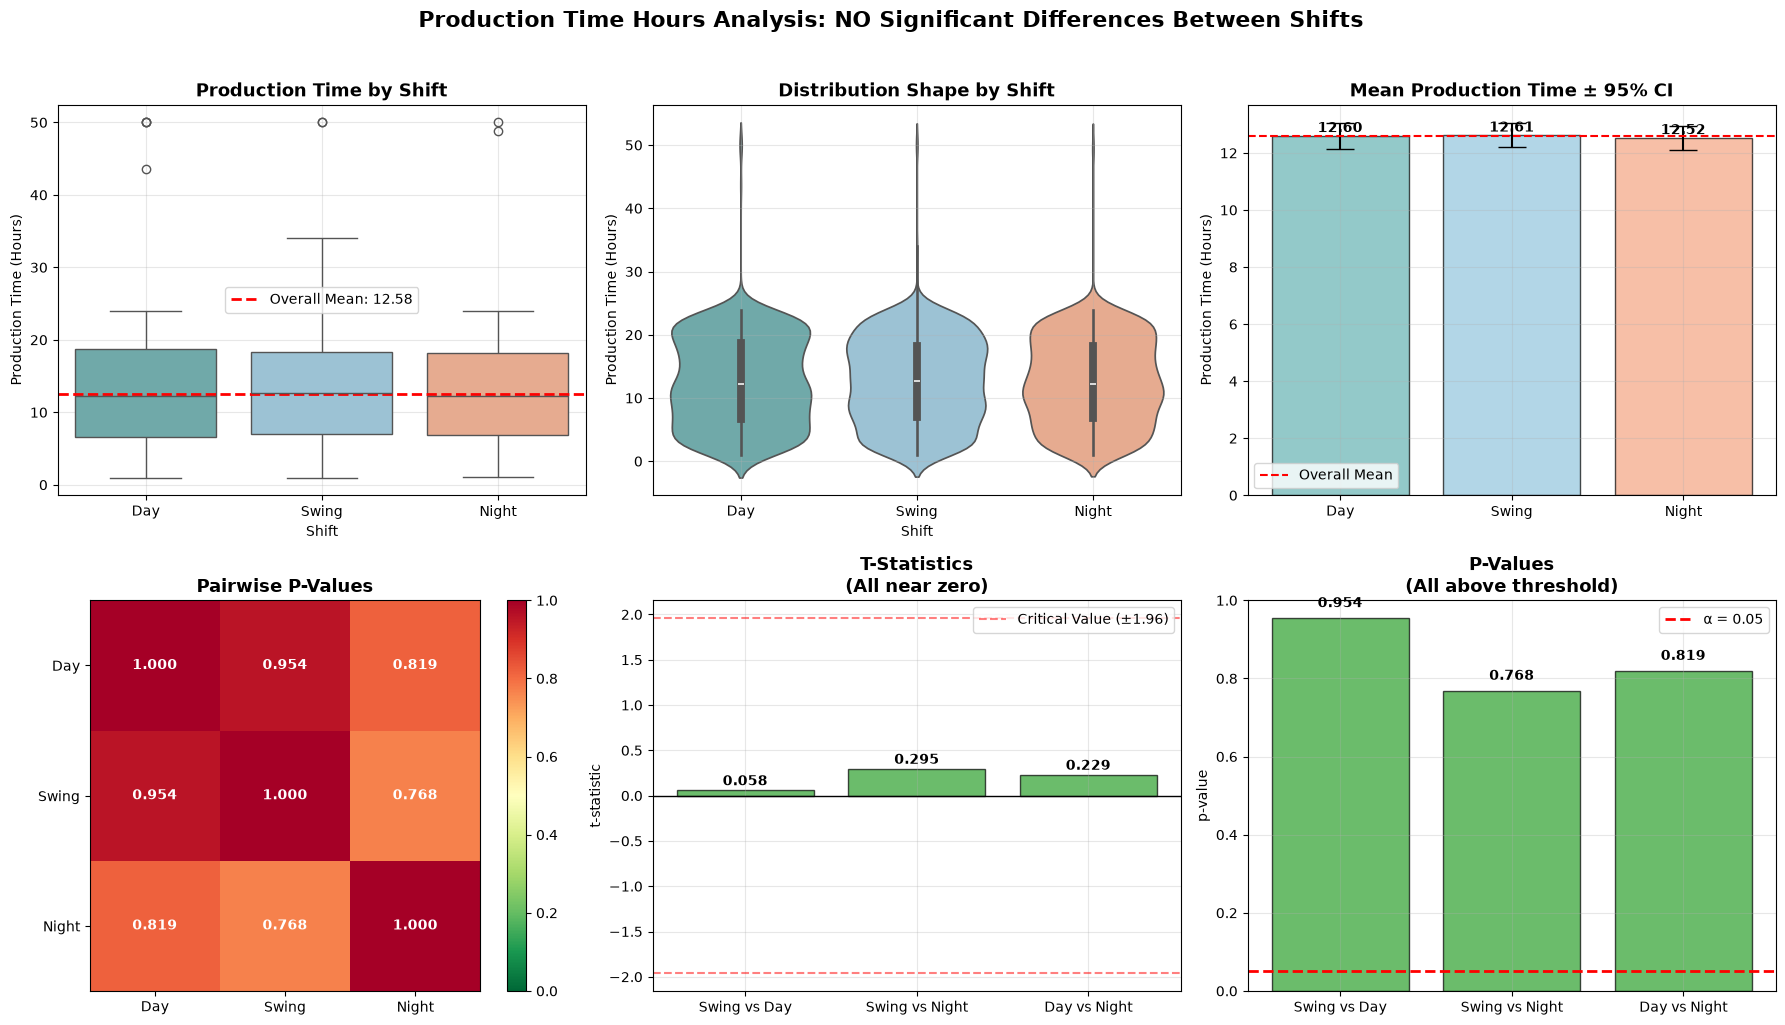

In [112]:
# Create comprehensive visualization for Production Time Hours
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Box Plot
ax1 = axes[0, 0]
sns.boxplot(data=df, x='Shift', y='Production Time Hours',
            order=['Day', 'Swing', 'Night'],
            palette=['#66b3b2', '#92c5de', '#f4a582'], ax=ax1)
ax1.set_title('Production Time by Shift', fontsize=13, fontweight='bold')
ax1.set_ylabel('Production Time (Hours)')
ax1.axhline(y=df['Production Time Hours'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Overall Mean: {df["Production Time Hours"].mean():.2f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Violin Plot (shows distribution better)
ax2 = axes[0, 1]
sns.violinplot(data=df, x='Shift', y='Production Time Hours',
               order=['Day', 'Swing', 'Night'],
               palette=['#66b3b2', '#92c5de', '#f4a582'], ax=ax2)
ax2.set_title('Distribution Shape by Shift', fontsize=13, fontweight='bold')
ax2.set_ylabel('Production Time (Hours)')
ax2.grid(True, alpha=0.3)

# 3. Means with Confidence Intervals
ax3 = axes[0, 2]
means = df.groupby('Shift')['Production Time Hours'].mean().reindex(['Day', 'Swing', 'Night'])
stds = df.groupby('Shift')['Production Time Hours'].std().reindex(['Day', 'Swing', 'Night'])
n = df.groupby('Shift')['Production Time Hours'].count().reindex(['Day', 'Swing', 'Night'])

se = stds / np.sqrt(n)
x_pos = np.arange(len(means))

bars = ax3.bar(x_pos, means, yerr=1.96*se, capsize=10,
               color=['#66b3b2', '#92c5de', '#f4a582'],
               alpha=0.7, edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(means.index)
ax3.set_title('Mean Production Time ± 95% CI', fontsize=13, fontweight='bold')
ax3.set_ylabel('Production Time (Hours)')
ax3.axhline(y=df['Production Time Hours'].mean(), color='red', 
            linestyle='--', label='Overall Mean')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, mean_val in zip(bars, means):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold')

# 4. P-value Heatmap
ax4 = axes[1, 0]
p_values = np.array([
    [1, 0.954, 0.819],
    [0.954, 1, 0.768],
    [0.819, 0.768, 1]
])
im = ax4.imshow(p_values, cmap='RdYlGn_r', vmin=0, vmax=1)
ax4.set_xticks(range(3))
ax4.set_yticks(range(3))
ax4.set_xticklabels(['Day', 'Swing', 'Night'])
ax4.set_yticklabels(['Day', 'Swing', 'Night'])
ax4.set_title('Pairwise P-Values', fontsize=13, fontweight='bold')

for i in range(3):
    for j in range(3):
        text = ax4.text(j, i, f'{p_values[i, j]:.3f}',
                       ha="center", va="center", 
                       color="black" if p_values[i, j] < 0.7 else "white",
                       fontweight='bold')
plt.colorbar(im, ax=ax4)

# 5. T-statistics Bar Chart
ax5 = axes[1, 1]
comparisons = ['Swing vs Day', 'Swing vs Night', 'Day vs Night']
t_stats = [0.058, 0.295, 0.229]
colors_bar = ['#2ca02c' for _ in t_stats]  # All green since near zero

bars = ax5.bar(comparisons, t_stats, color=colors_bar, alpha=0.7, edgecolor='black')
ax5.axhline(0, color='black', linewidth=1)
ax5.axhline(1.96, color='red', linestyle='--', alpha=0.5, label='Critical Value (±1.96)')
ax5.axhline(-1.96, color='red', linestyle='--', alpha=0.5)
ax5.set_title('T-Statistics\n(All near zero)', fontsize=13, fontweight='bold')
ax5.set_ylabel('t-statistic')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Add t-stat values on bars
for bar, t_val in zip(bars, t_stats):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{t_val:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. P-value Bar Chart
ax6 = axes[1, 2]
p_vals = [0.954, 0.768, 0.819]
colors_p = ['#2ca02c' if x > 0.05 else '#d62728' for x in p_vals]

bars = ax6.bar(comparisons, p_vals, color=colors_p, alpha=0.7, edgecolor='black')
ax6.axhline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax6.set_title('P-Values\n(All above threshold)', fontsize=13, fontweight='bold')
ax6.set_ylabel('p-value')
ax6.set_ylim(0, 1)
ax6.legend()
ax6.grid(True, alpha=0.3)

# Add p-value labels on bars
for bar, p_val in zip(bars, p_vals):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{p_val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Production Time Hours Analysis: NO Significant Differences Between Shifts', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 BUSINESS IMPLICATION:                                               
 - Production time does NOT vary by shift schedule                       
 - All shifts operate with similar production time                      
 -  Shift scheduling has NO impact on production duration     

## Monthly Production Trends:

- How does the average number of units produced change from month to month? Look for any patterns, such as times of the year when production increases or decreases significantly.

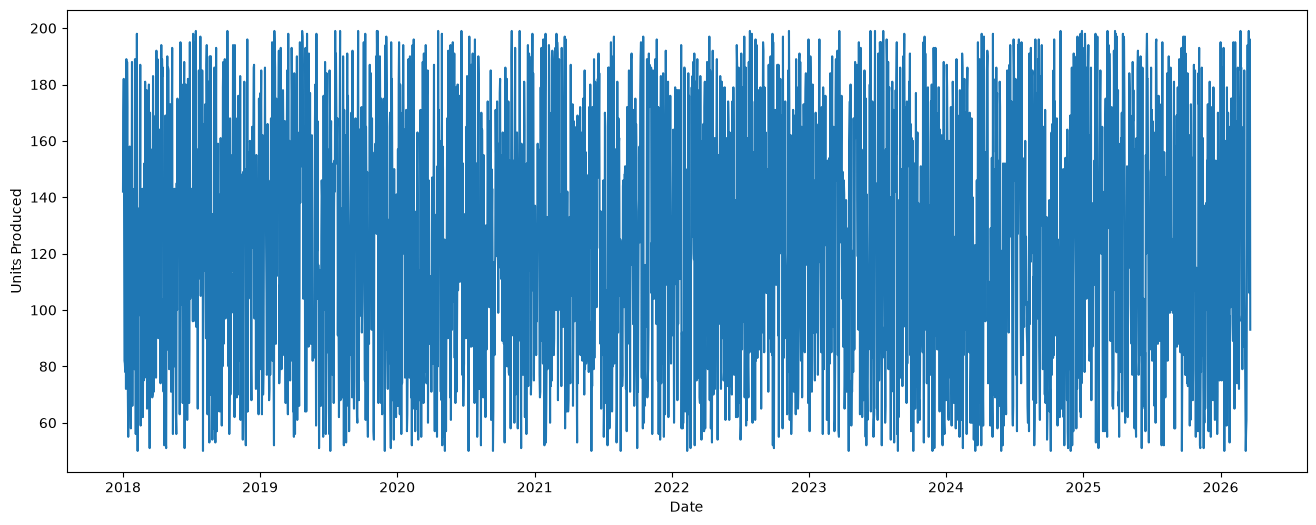

In [113]:
plt.figure(figsize=(16,6))
ax=sns.lineplot(y=df['Units Produced'],x=df.Date)

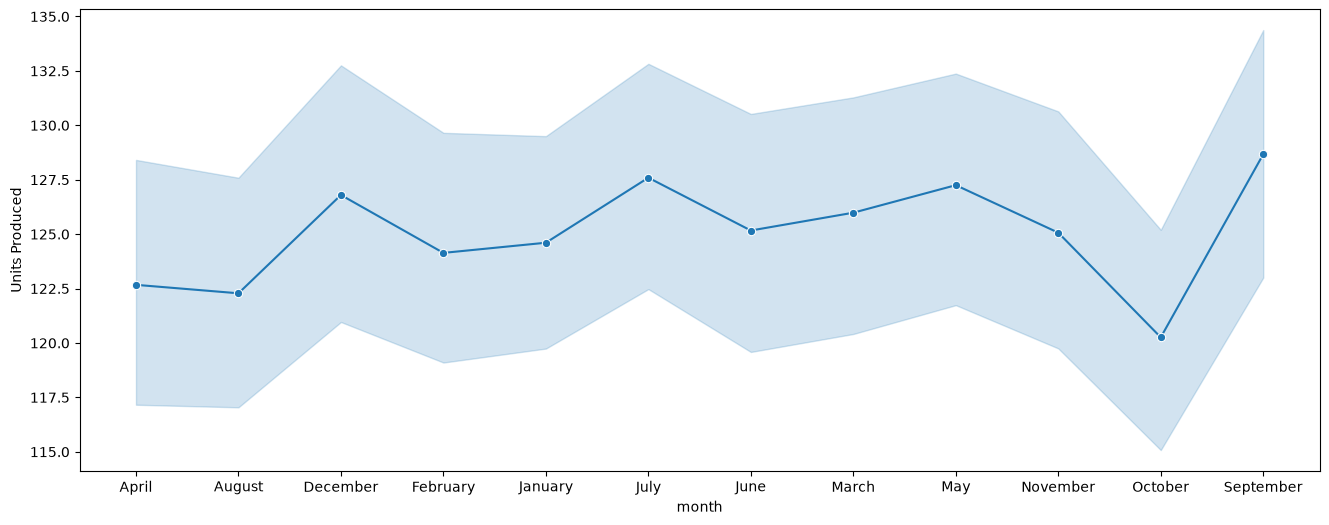

In [115]:
plt.figure(figsize=(16,6))
ax=sns.lineplot(y=df['Units Produced'],x=df.month,marker='o')

- In December, July, May and september have the highest unit produced.
- In August, June, November and October have the lowest unit produced.

## Variability in Production by Product Type:

- Which type of product shows the most variation in how much is produced? Measure this using standard deviation to find out which product type's production volume varies the most.

In [116]:
stdev=df.groupby('Product Type')['Production Volume Cubic Meters'].std()


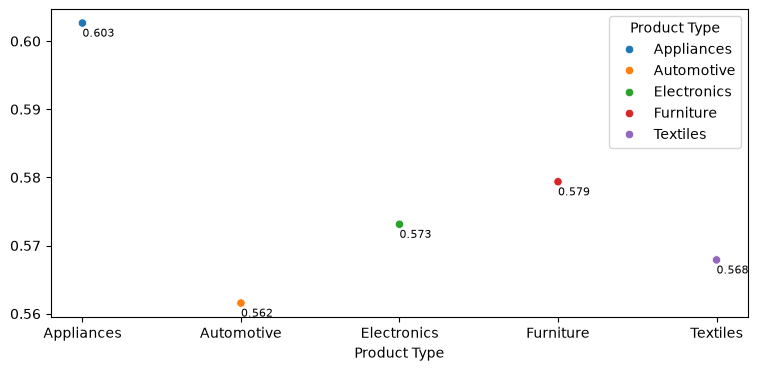

In [118]:
plt.figure(figsize=(9,4))
ax = sns.scatterplot(x=stdev.index, y=stdev.values, hue=stdev.index)

for i in range(len(stdev)):
    plt.annotate(
        round(stdev.iloc[i], 3),  # Use .iloc for position-based access
        (stdev.index[i], stdev.iloc[i] - 0.002),
        size=8
    )

plt.show()


 Appliances show the MOST variation, Automotive shows the LEAST variation.

In [121]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent', 'month'],
      dtype='str')

In [123]:
stdev=df.groupby('Product Type')['Units Produced'].std()


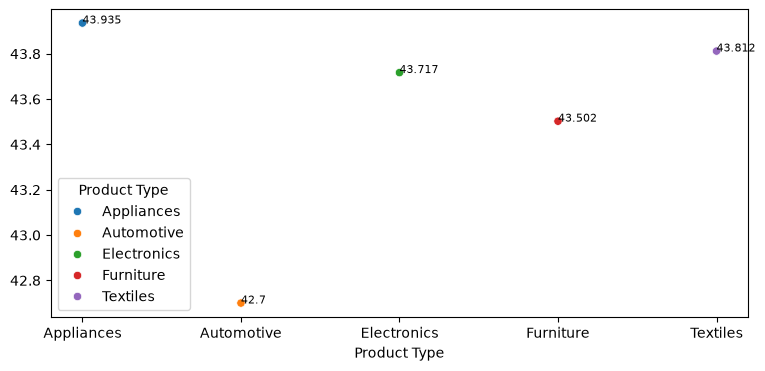

In [124]:
plt.figure(figsize=(9,4))
ax = sns.scatterplot(x=stdev.index, y=stdev.values, hue=stdev.index)

for i in range(len(stdev)):
    plt.annotate(
        round(stdev.iloc[i], 3),  # Use .iloc for position-based access
        (stdev.index[i], stdev.iloc[i] - 0.002),
        size=8
    )

plt.show()


## The Role of Operator Count in Efficiency:

- How does the number of operators affect how many units are produced per hour? Check if having more operators leads to more efficient production.

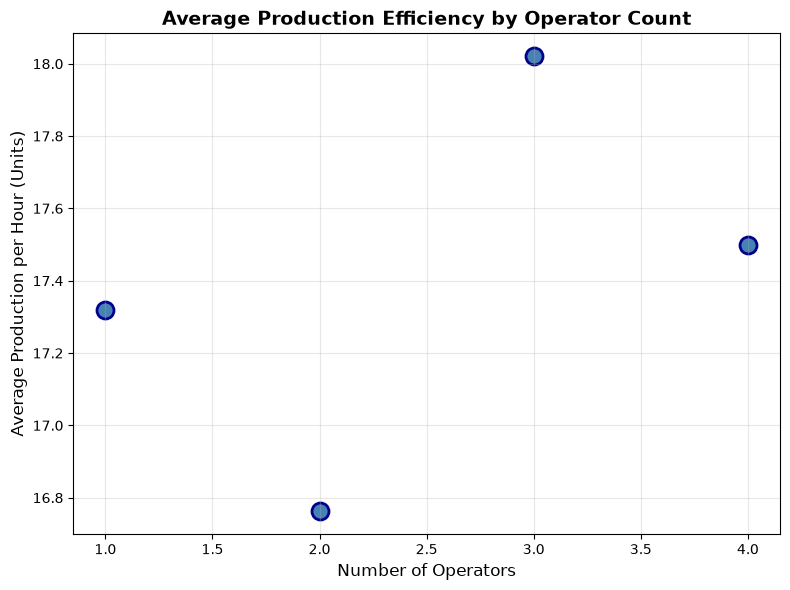

In [8]:
# Calculate production per hour
df['Production per hour'] = df['Units Produced'] / df['Production Time Hours']

# Calculate mean production per hour for each operator count
avg_production = df.groupby('Operator Count')['Production per hour'].mean().reset_index()

# Create scatter plot with only the mean values
plt.figure(figsize=(8, 6))
plt.scatter(avg_production['Operator Count'], avg_production['Production per hour'], 
            s=150, color='steelblue', edgecolors='darkblue', linewidth=2)

# Labels and title
plt.xlabel('Number of Operators', fontsize=12)
plt.ylabel('Average Production per Hour (Units)', fontsize=12)
plt.title('Average Production Efficiency by Operator Count', fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [142]:
# See sample size for each operator count
print(df.groupby('Operator Count')['Production per hour'].agg(['count', 'mean', 'std']))

                count       mean        std
Operator Count                             
1                 748  17.319687  20.729783
2                 770  16.763033  20.033839
3                 731  18.021761  23.101706
4                 751  17.499939  20.626469


The pattern suggests 3 operators is the optimal team size for your production process. This is actually very common in manufacturing:

- Too few (1-2): Not enough hands to do all tasks efficiently

- Optimal (3): Perfect - one preparing, one operating, one quality checking

- Too many (4): People getting in each other's way, waiting for turns

## Identifying the Machine with Most Defects:

- Which machine tends to produce the most defects, considering the total units it produces? Calculate the defect rate as defects per 100 units to make comparisons easier.

In [146]:
df['Defect Rate per 100 units produced']=df['Defects']*100/df['Units Produced']

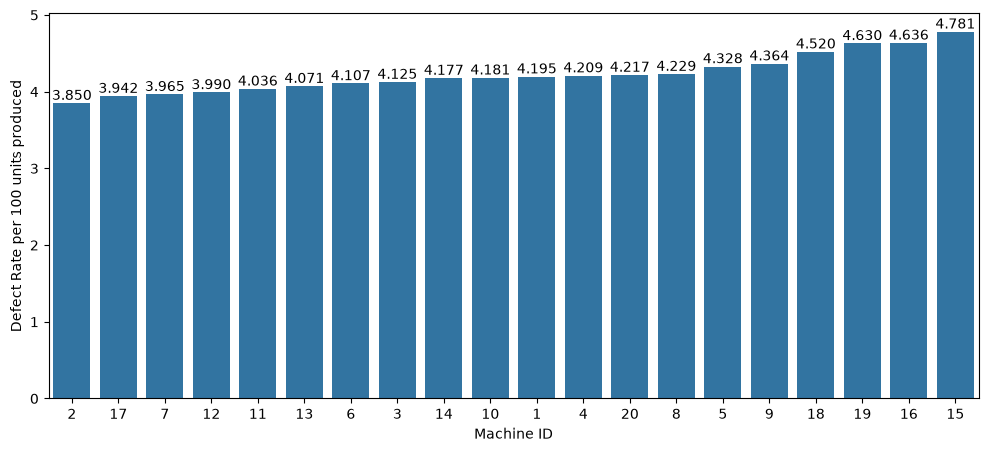

In [148]:
plt.figure(figsize=(12,5))
mdef=df.groupby('Machine ID')['Defect Rate per 100 units produced'].mean()
mdefr=pd.DataFrame(mdef)
ax=sns.barplot(x=df['Machine ID'],y=df['Defect Rate per 100 units produced'],errorbar=None,
         order=mdefr.sort_values(by='Defect Rate per 100 units produced').index)
ax.bar_label(ax.containers[0],fmt="%0.3f")
plt.show()

Machine 7,17,2 have the lowest Defect Rate, whereas Machine 19,15,16 have the highest defect rate

## How Environment Affects Scrap Rate:

- Do changes in temperature and humidity affect how much scrap (waste) is produced? Analyze the data to see if there's a correlation between environmental conditions and scrap rate.

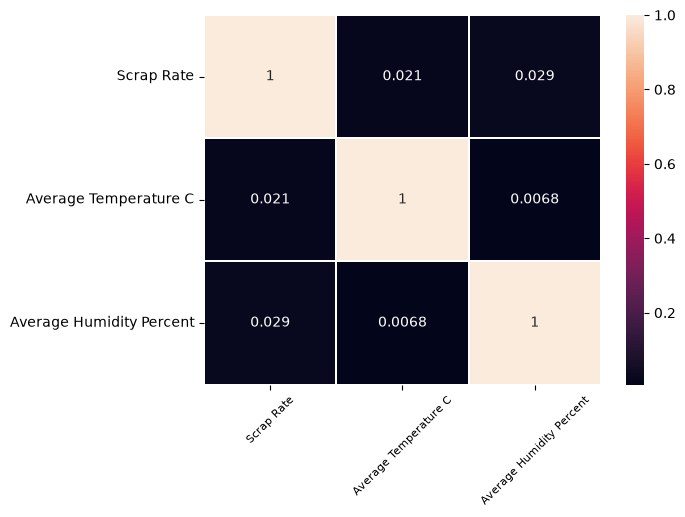

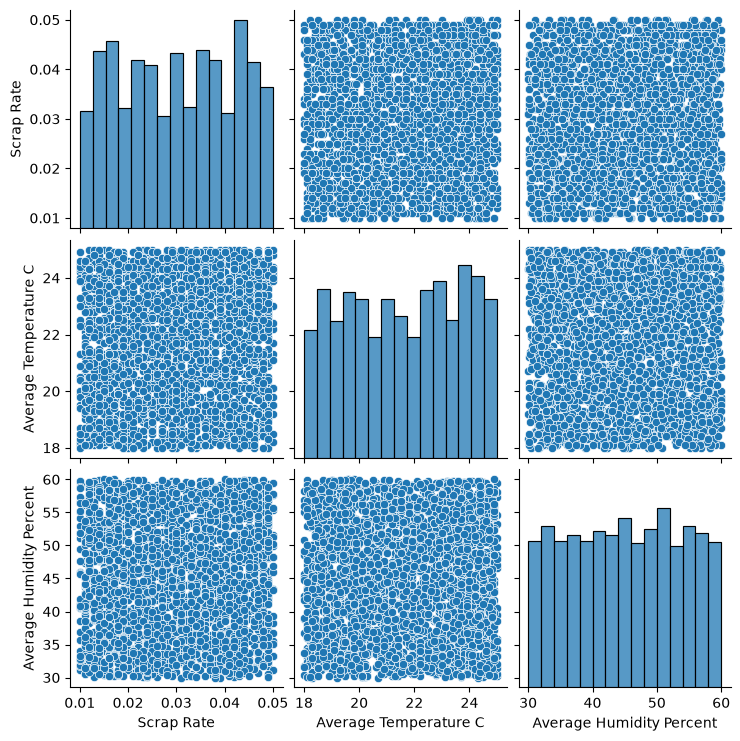

In [150]:
numer=['Scrap Rate','Average Temperature C','Average Humidity Percent'] 
g=sns.heatmap(df[numer].corr(),annot=True,linewidth=0.2)
g.set_xticklabels(g.get_xticklabels(), rotation = 45, fontsize = 8)
sns.pairplot(df[numer])

From the visual it is clear that there are no correlation of scrap with temperature and humidity 

In [151]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent', 'month', 'Production per hour',
       'Defect Rate per 100 units produced'],
      dtype='str')

Which specific Machine IDs accumulate the highest ratio of Down Time Hours compared to active Production Time Hours?

In [160]:
df['down_time_to_production_time_ratio'] = df['Down time Hours'] / df['Production Time Hours']


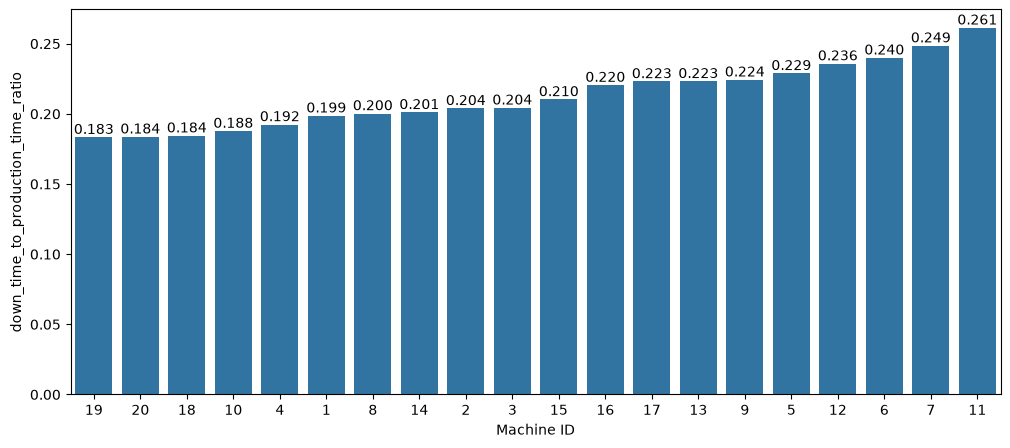

In [161]:
plt.figure(figsize=(12,5))
mdtm=df.groupby('Machine ID')['down_time_to_production_time_ratio'].mean()
mdtma=pd.DataFrame(mdtm)
ax=sns.barplot(x=df['Machine ID'],y=df['down_time_to_production_time_ratio'],errorbar=None,
         order=mdtma.sort_values(by='down_time_to_production_time_ratio').index)
ax.bar_label(ax.containers[0],fmt="%0.3f")
plt.show()

- Machine 4, 10, 18, 19, 20 have lowest down time to production time ratio.
- machine 5, 6, 7, 11, 12 have highest down time to production time ratio.

Is there a point of diminishing returns where high Maintenance Hours do not lead to a drop in Down Time Hours?

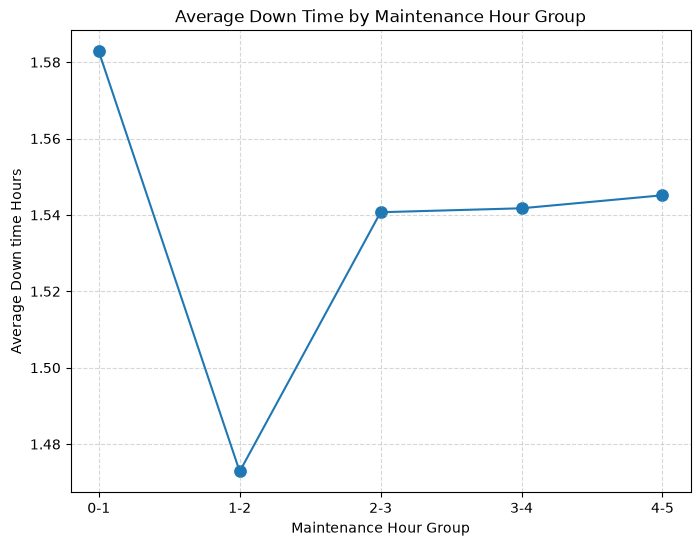

In [158]:


# Create maintenance-hour groups
bins = [0, 1, 2 ,3, 4, 5]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5"]

df["Maintenance Group"] = pd.cut(
    df["Maintenance Hours"],
    bins=bins,
    labels=labels
)

# Calculate average downtime for each group
grouped = (
    df.groupby("Maintenance Group", observed=True)["Down time Hours"]
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=grouped,
    x="Maintenance Group",
    y="Down time Hours",
    s=100
)

plt.plot(grouped["Maintenance Group"], grouped["Down time Hours"], marker="o")

plt.title("Average Down Time by Maintenance Hour Group")
plt.xlabel("Maintenance Hour Group")
plt.ylabel("Average Down time Hours")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The results suggest a point of diminishing returns at approximately the 1–2 maintenance hour group. Up to this point, increasing maintenance is associated with lower downtime. Beyond this level, further increases in maintenance hours do not produce additional reductions in downtime, indicating that the benefit of extra maintenance has diminished.

## Save the cleand and processed data 

In [162]:
df.to_csv("cleaned_data.csv", index=False)